In [64]:
import tensorflow as tf
import numpy as np
import random
import os

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

## Read CWRU Bearing Data (Load - 2HP)

In [2]:
folder_path = './CWRU_BearingData_Load_2HP' 

# Create a dictionary to hold data and labels
data_dict = {
    'Condition': [],
    'Fault Size (mm)': [],
    'Fault Label': [],
    'Signal': []
}

# Add data from each condition

# Normal
file_path = os.path.join(folder_path, '99.mat')
X99_normal = scipy.io.loadmat(file_path)['X099_DE_time']
data_dict['Condition'].append('Normal')
data_dict['Fault Size (mm)'].append(0)
data_dict['Fault Label'].append(0)
data_dict['Signal'].append(X99_normal.flatten())

# RE 0.18
file_path = os.path.join(folder_path, '124.mat')
X124_Ball_018 = scipy.io.loadmat(file_path)['X124_DE_time']
data_dict['Condition'].append('RE (Rolling element)')
data_dict['Fault Size (mm)'].append(0.18)
data_dict['Fault Label'].append(1)
data_dict['Signal'].append(X124_Ball_018.flatten())

# IR 0.18
file_path = os.path.join(folder_path, '111.mat')
X111_InnerRace_018 = scipy.io.loadmat(file_path)['X111_DE_time']
data_dict['Condition'].append('IR (Inner ring)')
data_dict['Fault Size (mm)'].append(0.18)
data_dict['Fault Label'].append(2)
data_dict['Signal'].append(X111_InnerRace_018.flatten())

# OR 0.18
file_path = os.path.join(folder_path, '137.mat')
X137_OuterRace_018 = scipy.io.loadmat(file_path)['X137_DE_time']
data_dict['Condition'].append('OR (Outer ring)')
data_dict['Fault Size (mm)'].append(0.18)
data_dict['Fault Label'].append(3)
data_dict['Signal'].append(X137_OuterRace_018.flatten())

# RE 0.36
file_path = os.path.join(folder_path, '191.mat')
X191_Ball_036 = scipy.io.loadmat(file_path)['X191_DE_time']
data_dict['Condition'].append('RE (Rolling element)')
data_dict['Fault Size (mm)'].append(0.36)
data_dict['Fault Label'].append(4)
data_dict['Signal'].append(X191_Ball_036.flatten())

# IR 0.36
file_path = os.path.join(folder_path, '176.mat')
X176_InnerRace_036 = scipy.io.loadmat(file_path)['X176_DE_time']
data_dict['Condition'].append('IR (Inner ring)')
data_dict['Fault Size (mm)'].append(0.36)
data_dict['Fault Label'].append(5)
data_dict['Signal'].append(X176_InnerRace_036.flatten())

# OR 0.36
file_path = os.path.join(folder_path, '203.mat')
X203_OuterRace_036 = scipy.io.loadmat(file_path)['X203_DE_time']
data_dict['Condition'].append('OR (Outer ring)')
data_dict['Fault Size (mm)'].append(0.36)
data_dict['Fault Label'].append(6)
data_dict['Signal'].append(X203_OuterRace_036.flatten())

# RE 0.54
file_path = os.path.join(folder_path, '228.mat')
X228_Ball_054 = scipy.io.loadmat(file_path)['X228_DE_time']
data_dict['Condition'].append('RE (Rolling element)')
data_dict['Fault Size (mm)'].append(0.54)
data_dict['Fault Label'].append(7)
data_dict['Signal'].append(X228_Ball_054.flatten())

# IR 0.54
file_path = os.path.join(folder_path, '215.mat')
X215_InnerRace_054 = scipy.io.loadmat(file_path)['X215_DE_time']
data_dict['Condition'].append('IR (Inner ring)')
data_dict['Fault Size (mm)'].append(0.54)
data_dict['Fault Label'].append(8)
data_dict['Signal'].append(X215_InnerRace_054.flatten())

# OR 0.54
file_path = os.path.join(folder_path, '240.mat')
X240_OuterRace_054 = scipy.io.loadmat(file_path)['X240_DE_time']
data_dict['Condition'].append('OR (Outer ring)')
data_dict['Fault Size (mm)'].append(0.54)
data_dict['Fault Label'].append(9)
data_dict['Signal'].append(X240_OuterRace_054.flatten())


## Data Processing and Feature Extraction with Imbalanced Data


In [9]:
# Convert dictionary to a DataFrame
df = pd.DataFrame(data_dict)

# Display the DataFrame
print(df)

# Function to preprocess data for imbalance with different points for each label
def preprocess_data_for_imbalance(df, start_point_dict, num_points_dict):
    """
    Preprocess data by selecting a section of the signal for each fault label
    based on a given start point and number of points for each label.

    Args:
        df (pd.DataFrame): Input DataFrame containing signals and labels.
        start_point_dict (dict): Dictionary specifying the start point for each label.
        num_points_dict (dict): Dictionary specifying the number of points for each label.

    Returns:
        pd.DataFrame: Processed DataFrame with signals for each label.
    """
    processed_data = {
        'Condition': [],
        'Fault Size (mm)': [],
        'Fault Label': [],
        'Signal': []
    }

    for fault_label in df['Fault Label'].unique():
        subset = df[df['Fault Label'] == fault_label]
        if subset.empty:
            continue

        signal = subset.iloc[0]['Signal']
        condition = subset.iloc[0]['Condition']
        fault_size = subset.iloc[0]['Fault Size (mm)']

        # Get start point and number of points for the current label
        start_point = start_point_dict.get(fault_label, 0)  # Default start_point is 0
        num_points = num_points_dict.get(fault_label, len(signal))  # Default is full signal length

        # Validate range
        if start_point >= len(signal):
            print(f"Start point {start_point} is out of range for signal with length {len(signal)}. Skipping Fault Label {fault_label}.")
            continue

        end_point = min(start_point + num_points, len(signal))
        signal_section = signal[start_point:end_point]

        # Append to processed data
        processed_data['Condition'].append(condition)
        processed_data['Fault Size (mm)'].append(fault_size)
        processed_data['Fault Label'].append(fault_label)
        processed_data['Signal'].append(signal_section)

    return pd.DataFrame(processed_data)

# Function to plot signals after preprocessing
def plot_preprocessed_signals(df_imbalance):
    """
    Plot the preprocessed signals for each fault label.

    Args:
        df_imbalance (pd.DataFrame): Processed DataFrame containing signals and labels.
    """
    for fault_label in df_imbalance['Fault Label'].unique():
        subset = df_imbalance[df_imbalance['Fault Label'] == fault_label]
        if subset.empty:
            continue

        signal = subset.iloc[0]['Signal']
        condition = subset.iloc[0]['Condition']
        fault_size = subset.iloc[0]['Fault Size (mm)']

        plt.figure(figsize=(10, 6))
        plt.plot(signal, color='blue', linewidth=1)
        plt.title(f"Preprocessed Signal - {condition} (Fault Label: {fault_label}, Fault Size: {fault_size} mm)")
        plt.xlabel("Time Steps")
        plt.ylabel("Signal")
        plt.grid(True)
        plt.show()


# Example: Define start points and number of points for each label
start_point_dict_train = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    8: 0,
    9: 0
}

# For IR = 50:1
num_points_dict_train = {
    0: 480000,
    1: 9600,
    2: 9600,
    3: 9600,
    4: 9600,
    5: 9600,
    6: 9600,
    7: 9600,
    8: 9600,
    9: 9600
}

"""
num_points_dict_train = {
    0: 240000,
    1: 120000,
    2: 120000,
    3: 120000,
    4: 120000,
    5: 120000,
    6: 120000,
    7: 120000,
    8: 120000,
    9: 120000
}


start_point_dict_test = {
    0: 240000,
    1: 120000,
    2: 120000,
    3: 120000,
    4: 120000,
    5: 120000,
    6: 120000,
    7: 120000,
    8: 120000,
    9: 120000
}

num_points_dict_test = {
    0: 24000,
    1: 24000,
    2: 24000,
    3: 24000,
    4: 24000,
    5: 24000,
    6: 24000,
    7: 24000,
    8: 24000,
    9: 24000
}
"""

# Preprocess data and save to df_imbalance
df_imbalance_train = preprocess_data_for_imbalance(df, start_point_dict_train, num_points_dict_train)
# df_imbalance_test = preprocess_data_for_imbalance(df, start_point_dict_test, num_points_dict_test)

# Inspect df_imbalance_train for signal lengths per condition
print("df_imbalance_train Overview:")
print(df_imbalance_train)

# Calculate and display the length of each signal
signal_lengths = df_imbalance_train['Signal'].apply(len)
df_imbalance_train['Signal Length'] = signal_lengths

# Group by condition and fault label to summarize lengths
length_summary = df_imbalance_train.groupby(['Condition', 'Fault Label', 'Fault Size (mm)'])['Signal Length'].agg(['min', 'max', 'count']).reset_index()
print("\nSignal Length Summary by Condition:")
print(length_summary)

# Display detailed breakdown per fault label
for index, row in df_imbalance_train.iterrows():
    print(f"Condition: {row['Condition']}, Fault Label: {row['Fault Label']}, Fault Size: {row['Fault Size (mm)']} mm, Signal Length: {len(row['Signal'])}")

# # Plot preprocessed signals
# plot_preprocessed_signals(df_imbalance_train)
# plot_preprocessed_signals(df_imbalance_test)



              Condition  Fault Size (mm)  Fault Label  \
0                Normal             0.00            0   
1  RE (Rolling element)             0.18            1   
2       IR (Inner ring)             0.18            2   
3       OR (Outer ring)             0.18            3   
4  RE (Rolling element)             0.36            4   
5       IR (Inner ring)             0.36            5   
6       OR (Outer ring)             0.36            6   
7  RE (Rolling element)             0.54            7   
8       IR (Inner ring)             0.54            8   
9       OR (Outer ring)             0.54            9   

                                              Signal  
0  [0.06425353846153846, 0.06300184615384616, -0....  
1  [0.09992676923076924, 0.14164984615384615, 0.1...  
2  [0.06133292307692308, -0.015646153846153844, -...  
3  [-0.967796, -1.7336026666666666, -2.226056, -2...  
4  [0.06446215384615385, 0.09575446153846154, 0.1...  
5  [0.16568133333333332, 0.116436, 0.0626,

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
import numpy as np

# Sampling function
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    """
    Split signal data into blocks with specified intervals and block size.
    
    Args:
        Data (np.array): Input signal data.
        interval_length (int): Step size for sampling.
        samples_per_block (int): Number of samples per block.
        ignore_points (int): Number of points to ignore at the start and end.
    
    Returns:
        np.array: Split data blocks.
    """
    # Adjust data length to ignore the first and last 'ignore_points'
    adjusted_length = len(Data) - 2 * ignore_points
    # Number of blocks
    No_of_blocks = (round(adjusted_length / interval_length) - round(samples_per_block / interval_length) - 1)
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    
    for i in range(No_of_blocks):
        # Skip the first 'ignore_points' and start sampling from that position
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx:(start_idx + samples_per_block)].T
    
    return SplitData

# Data preparation function
def DataPreparation(Data, interval_length, samples_per_block):
    """
    Prepare data by splitting and labeling for multi-class classification.
    
    Args:
        Data (list): List of signal data for all classes.
        interval_length (int): Step size for sampling.
        samples_per_block (int): Number of samples per block.
    
    Returns:
        tuple: Prepared data (X), positional labels (LabelPositional), and class labels (Label).
    """
    for count, signal in enumerate(Data):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        y = np.zeros([len(SplitData), 10])  # One-hot encoding
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])  # Class labels
        y1[:, 0] = count
        # Append data and labels
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    return X, LabelPositional, Label

# Prepare the train and test data
def prepare_datasets(df_imbalance, interval_length, samples_per_block):
    """
    Prepare train or test datasets using the DataPreparation function.
    
    Args:
        df_imbalance (pd.DataFrame): DataFrame containing signals and labels.
        interval_length (int): Interval length for sampling.
        samples_per_block (int): Number of samples per block.
    
    Returns:
        tuple: X (input data), y (one-hot labels), y_class (class labels).
    """
    signals = df_imbalance['Signal'].tolist()
    X, y_positional, y_class = DataPreparation(signals, interval_length, samples_per_block)
    return X, y_positional, y_class

# Set parameters
interval_length = 320
samples_per_block = 1600


# Prepare train and test datasets
X_train, y_train_positional, y_train = prepare_datasets(df_imbalance_train, interval_length, samples_per_block)

## Multiclass Classification CNN Model Training with Imbalanced Data


In [66]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#    X_train, y_train_positional, test_size=0.2, random_state=42, stratify=y_train_positional)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train_positional, y_train, test_size=0.2, random_state=42, stratify=y_train_positional)

print("Unique classes in y_train_positional_split:", np.unique(np.argmax(y_train_positional_split, axis=1)))
print("Unique classes in y_test_positional_split:", np.unique(np.argmax(y_test_positional_split, axis=1)))

Unique classes in y_train_positional_split: [0 1 2 3 4 5 6 7 8 9]
Unique classes in y_test_positional_split: [0 1 2 3 4 5 6 7 8 9]


In [67]:
condition_map = {0: "Normal", 1: "RE 0.18", 2: "IR 0.18", 3: "OR 0.18", 4: "RE 0.36", 
                 5: "IR 0.36", 6: "OR 0.36", 7: "RE 0.54", 8: "IR 0.54", 9: "OR 0.54"}

# X_train distribution
unique, counts = np.unique(np.argmax(y_train_positional, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({'Condition': [condition_map[l] for l in unique], 'Blocks': counts})
print("Blocks per class in X_train:")
print(df_train_orig.to_string(index=False))

# Train set distribution
train_classes = np.argmax(y_train_positional_split, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({'Condition': [condition_map[l] for l in unique_train], 'Blocks': counts_train})
print("\nX_train_split and y_train_positional_split distribution:")
print(df_train.to_string(index=False))

# Test set distribution
test_classes = np.argmax(y_test_positional_split, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({'Condition': [condition_map[l] for l in unique_test], 'Blocks': counts_test})
print("\nX_test_split and y_test_positional_split distribution:")
print(df_test.to_string(index=False))

# y_train_split and y_test_split (assuming same counts as positional)
print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Blocks per class in X_train:
Condition  Blocks
   Normal    1494
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

X_train_split and y_train_positional_split distribution:
Condition  Blocks
   Normal    1196
  RE 0.18      19
  IR 0.18      20
  OR 0.18      19
  RE 0.36      19
  IR 0.36      19
  OR 0.36      19
  RE 0.54      19
  IR 0.54      19
  OR 0.54      19

X_test_split and y_test_positional_split distribution:
Condition  Blocks
   Normal     298
  RE 0.18       5
  IR 0.18       4
  OR 0.18       5
  RE 0.36       5
  IR 0.36       5
  OR 0.36       5
  RE 0.54       5
  IR 0.54       5
  OR 0.54       5

y_train_split distribution (assumed):
Condition  Blocks
   Normal    1196
  RE 0.18      19
  IR 0.18      20
  OR 0.18      19
  RE 0.36      19
  IR 0.36      19
  OR 0.36      19
  RE 0.54      19
  IR 0.54      19
  OR 0.54      19

y_test_split distribution

In [ ]:
X_1D_train = X_train_split.reshape([-1, samples_per_block, 1])
X_1D_test = X_test_split.reshape([-1, samples_per_block, 1])
print(f"X_1D_train shape: {X_1D_train.shape}")  # Expected: (num_samples, 1600, 1)
print(f"X_1D_test shape: {X_1D_test.shape}")    # Expected: (num_samples, 1600, 1)
input_shape = (samples_per_block, 1)   # Reshaped input


class CNN_1D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv1D(filters=16, kernel_size=3, strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool1D(pool_size=2),
            
            layers.Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool1D(pool_size=2),

            layers.Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool1D(pool_size=2),

            layers.GlobalAveragePooling1D(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(10, activation='softmax')
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer='adam',
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['accuracy'])
        return model

Unique classes in y_train_positional_split: [0 1 2 3 4 5 6 7 8 9]
Unique classes in y_test_positional_split: [0 1 2 3 4 5 6 7 8 9]
X_1D_train shape: (1368, 1600, 1)
X_1D_test shape: (342, 1600, 1)


In [68]:
foldername = "CNN1D_results/IR_50_1_Pre_CNN1D_Raw_Set3_SKF_exp3/"

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.model_selection import StratifiedKFold

# Training with k-fold validation
from sklearn.metrics import balanced_accuracy_score

# Training with k-fold validation
kSplits = 5
# kfold = KFold(n_splits=kSplits, random_state=42, shuffle=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []  # Store balanced accuracy for each fold
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []  # Store balanced accuracy for test set

# early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# for train_idx, test_idx in kfold.split(X_1D_train, y_train_positional_split):
for fold, (train_idx, test_idx) in enumerate(kfold.split(X_1D_train, y_train_split)):

    # Define where to save the best model
    checkpoint_filepath = foldername + "best_model_" + str(fold+1) + ".h5"

    # Classification_1D = CNN_1D()
    # Classification_1D.model.fit(X_1D_train[train_idx], y_train_positional_split[train_idx],
    #                             validation_data=(X_1D_train[test_idx], y_train_positional_split[test_idx]),
    #                             epochs=200, callbacks=[early_stopping], verbose=1)

    # Create a ModelCheckpoint callback
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',  # Monitor validation accuracy
        save_best_only=True,  # Save only the best model
        mode='max',  # Maximize accuracy
        verbose=1
    ) 

    Classification_1D = CNN_1D()       
    history = Classification_1D.model.fit(
        X_1D_train[train_idx], y_train_positional_split[train_idx],
        validation_data=(X_1D_train[test_idx], y_train_positional_split[test_idx]),  # Validation set for monitoring
        epochs=50,
        verbose=1,
        callbacks=[checkpoint]  # Save the best model
    )

    print("Best model saved at:", checkpoint_filepath)
    CNN_1D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")
    
    # Train set metrics
    y_pred_proba_train = CNN_1D_best_model.predict(X_1D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))  # Balanced accuracy for train set
    
    # Test set metrics
    y_pred_proba_test = CNN_1D_best_model.predict(X_1D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))  # Balanced accuracy for test set

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_63 (Conv1D)              │ (None, 1600, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 1600, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_63 (MaxPooling1D) │ (None, 800, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_64 (Conv1D)              │ (None, 800, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 800, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_64 (MaxPooling1D) │ (None, 400, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_65 (Conv1D)              │ (None, 400, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_65 (MaxPooling1D) │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_21     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,098 (51.16 KB)

 Trainable params: 12,874 (50.29 KB)

...

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9947 - loss: 0.0259 - val_accuracy: 0.9853 - val_loss: 0.0417
Epoch 39/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9866 - loss: 0.0315
Epoch 39: val_accuracy did not improve from 0.98535
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9869 - loss: 0.0315 - val_accuracy: 0.9780 - val_loss: 0.0560
Epoch 40/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9899 - loss: 0.0278
Epoch 40: val_accuracy did not improve from 0.98535
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9897 - loss: 0.0282 - val_accuracy: 0.9707 - val_loss: 0.0622
Epoch 41/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9946 - loss: 0.0244
Epoch 41: val_accuracy did not improve from 0.98535
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9944 - loss: 0.0246 - val_accuracy: 0.9817 - val_loss: 0.0370
Epoch 42/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9874 - loss: 0.0252
Epoch 42: val_accuracy did not impro

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9988 - loss: 0.0131 - val_accuracy: 0.9963 - val_loss: 0.0198
Epoch 50/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9949 - loss: 0.0167
Epoch 50: val_accuracy did not improve from 0.99634
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.9744 - val_loss: 0.0429
Best model saved at: CNN1D_results/IR_50_1_Pre_CNN1D_Raw_Set3_SKF_exp3/best_model_5.h5


Best model loaded successfully!
 8/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

2025-06-23 15:04:05.147508: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-23 15:04:05.148448: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 99.68%
Test Accuracy: 99.12%
Train Precision: 99.73%
Test Precision: 99.19%
Train Recall: 99.68%
Test Recall: 99.12%
Train F1-score: 99.68%
Test F1-score: 99.12%
Train Log Loss: 0.0194
Test Log Loss: 0.0248
Train Balanced Accuracy: 97.68%
Test Balanced Accuracy: 94.00%
22/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


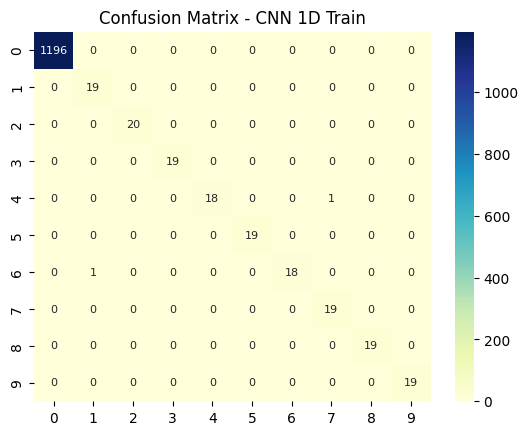

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


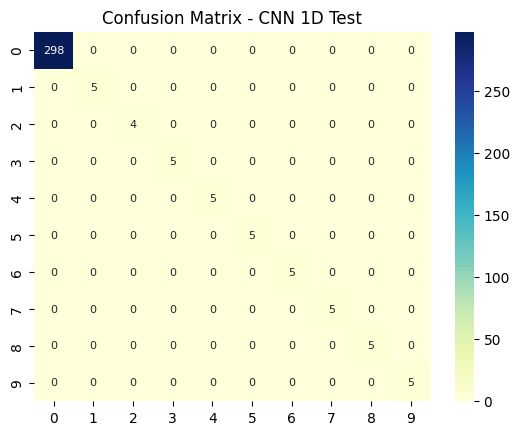

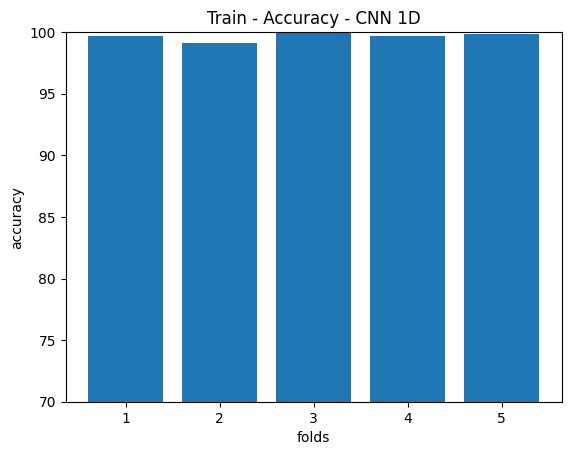

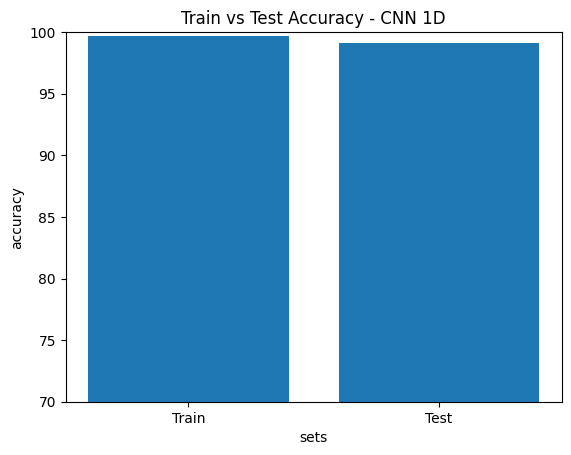

In [69]:
# Aggregated metrics
CNN_1D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_1D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_1D_train_precision = np.mean(precision_1D) * 100
CNN_1D_test_precision = np.mean(precision_1D_test) * 100
CNN_1D_train_recall = np.mean(recall_1D) * 100
CNN_1D_test_recall = np.mean(recall_1D_test) * 100
CNN_1D_train_f1 = np.mean(f1_1D) * 100
CNN_1D_test_f1 = np.mean(f1_1D_test) * 100
CNN_1D_train_log_loss = np.mean(log_loss_1D)
CNN_1D_test_log_loss = np.mean(log_loss_1D_test)
CNN_1D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_1D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_1D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_1D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_1D_train_precision:.2f}%")
print(f"Test Precision: {CNN_1D_test_precision:.2f}%")
print(f"Train Recall: {CNN_1D_train_recall:.2f}%")
print(f"Test Recall: {CNN_1D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_1D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_1D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_1D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_1D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_1D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_1D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 1D Train')
sns.heatmap(ConfusionMatrix(CNN_1D_best_model, X_1D_train, y_train_positional_split), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 1D Test')
sns.heatmap(ConfusionMatrix(CNN_1D_best_model, X_1D_test, y_test_positional_split), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 1D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_1D_train_accuracy, CNN_1D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()